In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_style('whitegrid')

virdis_colors = cm.viridis(np.linspace(0,1, 5))
primary_color = virdis_colors[0]
secondary_color = virdis_colors[1]
accent_color = virdis_colors[2]
danger_color = '#800000'
neutral_color = virdis_colors[3]
custom_pallete = virdis_colors

In [3]:
df = pd.read_csv(r'C:\Users\karan\Desktop\Projectt\Supply Chain Analysis\DataCoSupplyChainDataset.csv', encoding='latin-1')

## EDA

In [4]:
print("rows, cols :" , df.shape)
print('\ncolumns :', df.columns)
print(df.columns.to_list())
print("\nDuplicates :", df.duplicated().sum())
print("\nMissing Values (top 20):")
print(df.isnull().sum().sort_values(ascending=False).head(20))

rows, cols : (180519, 53)

columns : Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Pro

In [5]:
columns_to_drop = [
    'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Total',
    'Order Item Quantity',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Product Category Id',
    'Benefit per order',
    'Product Status',
    'Customer City',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market'
]

# Drop the specified columns from the DataFrame
df.drop(columns=columns_to_drop, inplace=True)






In [6]:
df = df[df['Delivery Status'] != 'Shipping canceled']

for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors = 'coerce', dayfirst=False)

print('rows. cols:', df.shape)
print('\n Missing values (top 10):')
print(df.isnull().sum().sort_values(ascending=False).head(10))

rows. cols: (172765, 20)

 Missing values (top 10):
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Name                    0
Customer Country                 0
Customer Segment                 0
Department Name                  0
dtype: int64


In [8]:
# value counts for categorical columns
for col in df.columns:
    if df[col].nunique() < 10:
        print(f'\n{col} value counts :')
        print(df[col].value_counts())


Type value counts :
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) value counts :
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Days for shipment (scheduled) value counts :
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Delivery Status value counts :
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Late_delivery_risk value counts :
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Customer Country value counts :
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Customer Segment value counts :
Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

Order Status value counts :
Order Status
CO

In [76]:
# calculating order proccessing time and delay
df['Order Processing Time'] = (df['shipping date (DateOrders)'] - df['order date (DateOrders)']).dt.days
df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']
df['Is_Delayed'] = df['Delay'] > 0
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day_name()
df['order_hour'] = df['order date (DateOrders)'].dt.hour
df.describe()



,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991936,0.120801,203.828493,22.032360,141.278595,2016-06-16 03:25:14.452927488,3.472816,0.539716,6.235511,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,7.030000,50.000000,2015-09-25 08:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 03:38:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 08:00:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,139.862956,NaN,1.670187,1.494150,3.405593,6.927276


In [10]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order Processing Time', 'Delay', 'Is_Delayed',
       'order_month', 'order_day', 'order_hour'],
      dtype='object')

In [8]:
df['Proffitaility Flag'] = np.where (df['Order Profit Per Order'] > 0, 'Profit', np.where(df['Order Profit Per Order'] < 0, 'Loss', 'Break Even' ))
df['Proffitaility Flag'].value_counts()

Proffitaility Flag
Profit        139354
Loss           32295
Break Even      1116
Name: count, dtype: int64

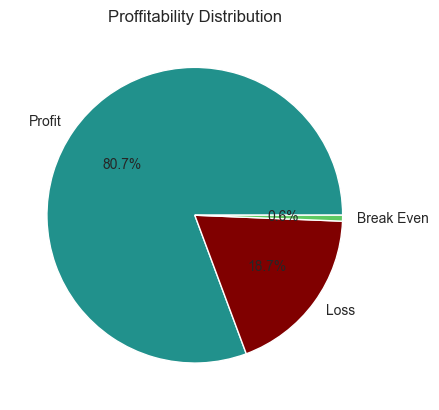

In [9]:
profit_counts = df['Proffitaility Flag'].value_counts(normalize=True) * 100
profit_counts.plot(kind = 'pie', autopct = '%1.1f%%', colors = [accent_color, danger_color, neutral_color])
plt.ylabel('')
plt.title('Proffitability Distribution')
plt.show()

In [10]:
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else :
        return f'{value:.0f} $'
    
delayed_df = df[df['Delay'] > 0]
metrics = {}
metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)
metrics['On time delivery %'] = (1 - metrics['Late Deliveries'] / metrics['Total Orders']) * 100
metrics['Late Delivery %'] = float(metrics['Late Deliveries'] / metrics['Total Orders']) * 100
metrics['Total Profit'] = format_func(df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum())
metrics['Total Loss due to delay'] = format_func(df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum())

print('\n----Business KPIs ----\n')
for k, v in metrics.items():
    if isinstance(v, float):
        print(f'{k} : {v:.2f}')
    else:        print(f'{k} : {v}')
                                      



----Business KPIs ----

Total Orders : 172765
Late Deliveries : 94523
90% Delay (days) : 3.00
On time delivery % : 45.29
Late Delivery % : 54.71
Total Profit : 7.5M $
Total Loss due to delay : 2.1M $


## Porfitability vs Delivery Time Analysis

In [11]:
profit_metrics = (
    df.groupby('Delay')['Order Profit Per Order'].agg(
        mean_profit = 'mean',
        total_profit = 'sum',
        order_count = 'count'
    )
    .reset_index()

) 

profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.249118,8.154302e+05,36650
3,1,22.333227,1.194895e+06,53503
4,2,21.128491,5.821110e+05,27551
5,3,20.031412,1.356527e+05,6772
6,4,21.368783,1.431067e+05,6697


In [12]:
delay_distribution = (
    df['Delay'].value_counts(normalize=True).sort_index() * 100
).reset_index()

delay_distribution

,Delay,proportion
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364



Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.249118,8.154302e+05,36650
3,1,22.333227,1.194895e+06,53503
4,2,21.128491,5.821110e+05,27551
5,3,20.031412,1.356527e+05,6772
6,4,21.368783,1.431067e+05,6697



Delay Distribution:


,Delay_Days,Percentage
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


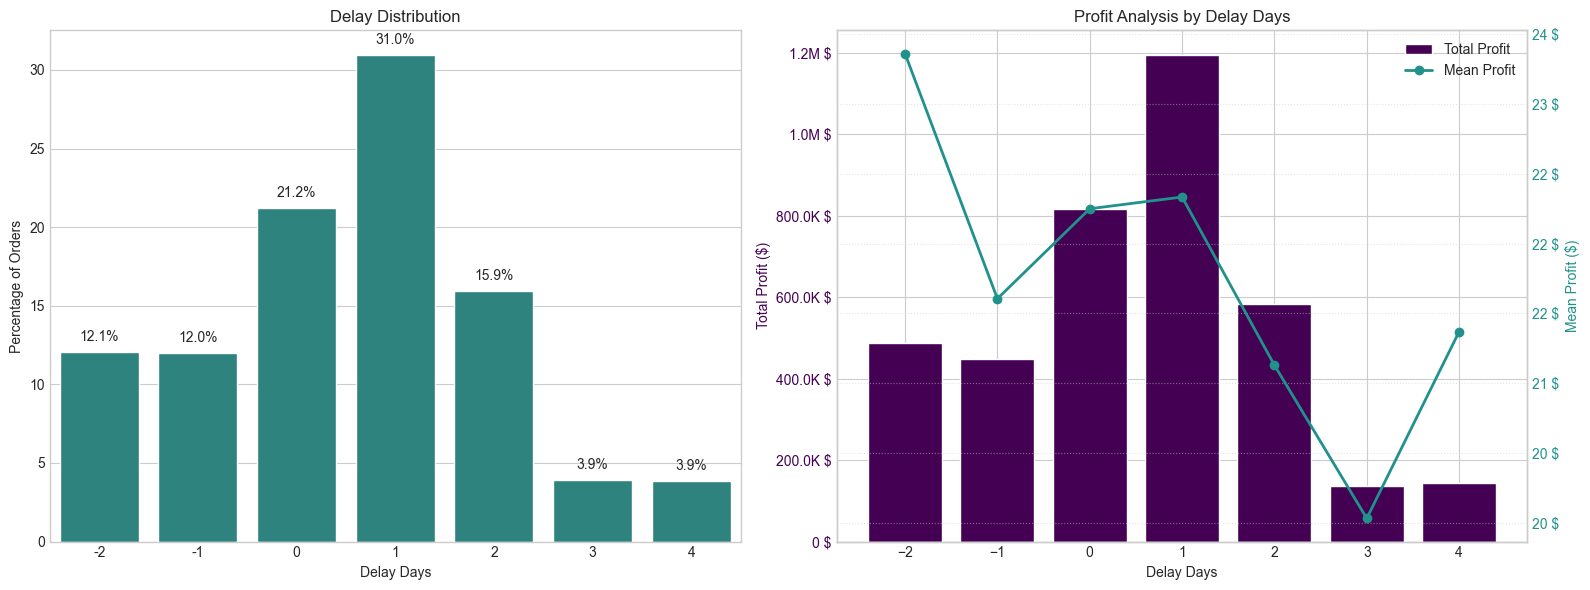

In [13]:
# Rename columns properly
delay_distribution.columns = ['Delay_Days', 'Percentage']


print('\nProfit Metrics by Delay Day:')
display(profit_metrics)

print('\nDelay Distribution:')
display(delay_distribution)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    x='Delay_Days',
    y='Percentage',
    data=delay_distribution,
    color=accent_color,
    ax=ax1
)

ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay Days')
ax1.set_ylabel('Percentage of Orders')

for bar in ax1.patches:
    height = bar.get_height()

    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )



# Bar chart for Total Profit
ax2.set_xlabel('Delay Days')
ax2.set_ylabel('Total Profit ($)', color=primary_color)

ax2.bar(
    profit_metrics['Delay'],
    profit_metrics['total_profit'],
    color=primary_color,
    label='Total Profit'
)

ax2.tick_params(axis='y', labelcolor=primary_color)

# Secondary axis for Mean Profit
ax3 = ax2.twinx()

ax3.set_ylabel('Mean Profit ($)', color=accent_color)

ax3.plot(
    profit_metrics['Delay'],
    profit_metrics['mean_profit'],
    marker='o',
    linewidth=2,
    color=accent_color,
    label='Mean Profit'
)

ax3.tick_params(axis='y', labelcolor=accent_color)


def format_func(value, tick_number):
    
    if value >= 1e6:
        return f'{value / 1e6:.1f}M $'
    
    elif value >= 1e3:
        return f'{value / 1e3:.1f}K $'
    
    else:
        return f'{value:.0f} $'

ax2.yaxis.set_major_formatter(
    ticker.FuncFormatter(format_func)
)

ax3.yaxis.set_major_formatter(
    ticker.FuncFormatter(format_func)
)

ax3.set_title('Profit Analysis by Delay Days')

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()

ax3.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='upper right'
)

ax3.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

## Bottleneck Detection

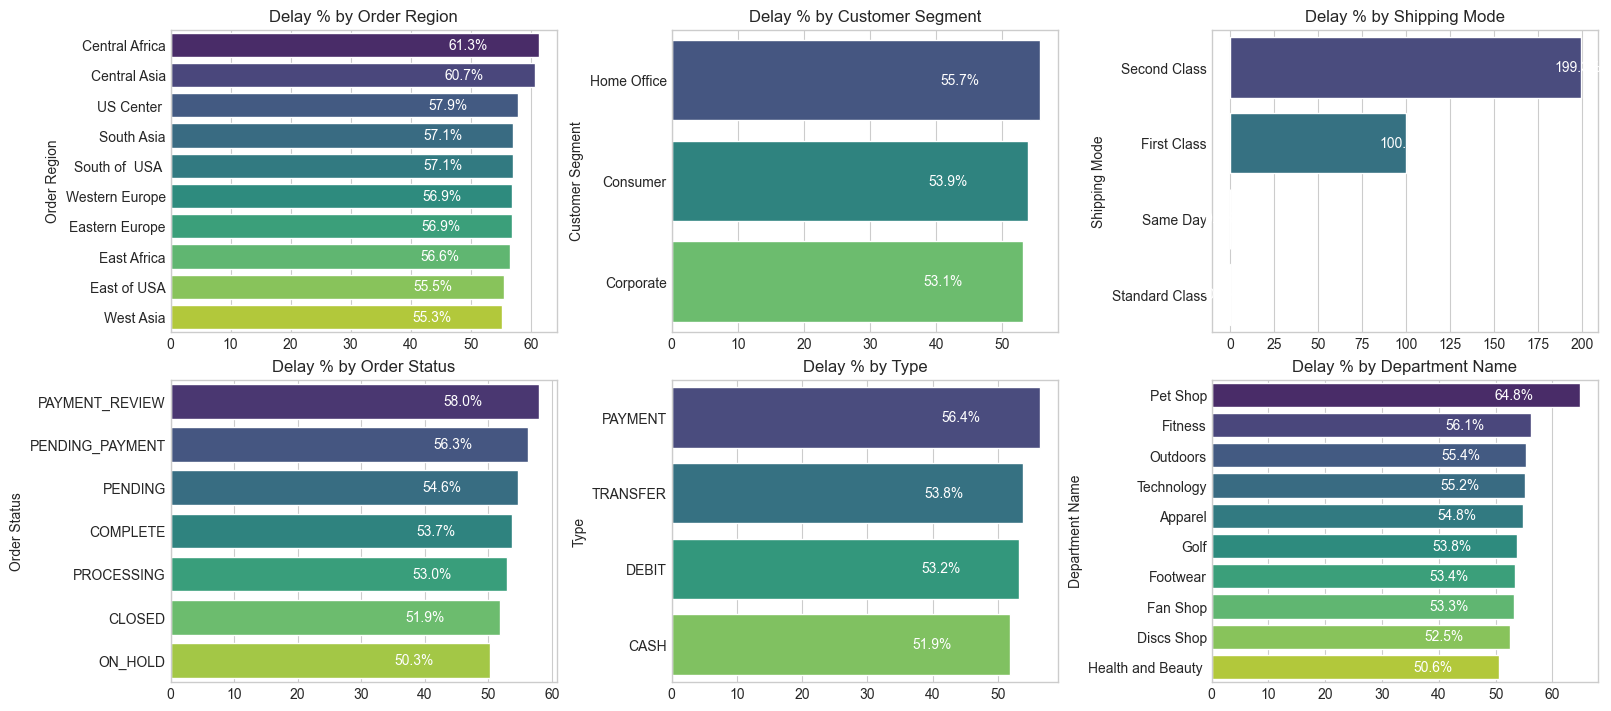

In [31]:
def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        Total_Orders = ('Delay', 'count'),
        late_Orders = ('Delay', 'sum')
    ).reset_index()
    cat_df['delay_pct'] = cat_df['late_Orders'] / cat_df['Total_Orders'] * 100
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)
    return cat_df 

categories = ['Order Region', 'Customer Segment', 'Shipping Mode', 'Order Status', 'Type', 'Department Name']

fig, axes = plt.subplots(2, 3, figsize=(16,7), constrained_layout=True)
axes = axes.flatten()

for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)
    
    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis'
    )
    
    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)
    
    for i , row in cat_df.reset_index().iterrows():
        ax.text(row['delay_pct'] - 15, i, f"{row['delay_pct']:.1f}%", va = 'center', fontsize=10, color = 'white' )

plt.show()

# ROOT CAUSE ANALYSIS

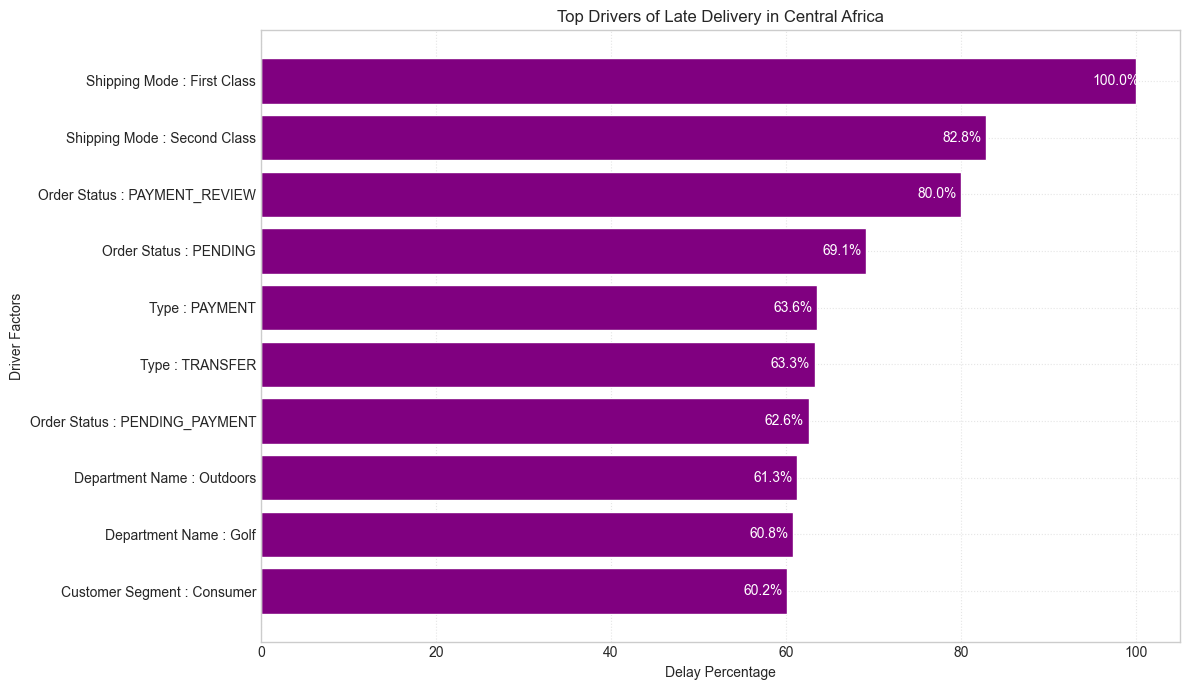

In [17]:
def top_drivers_for_region(region):
    df_region = df[df['Order Region'] == region].copy()

    drivers = [
        'Shipping Mode',
        'Customer Segment',
        'Order Status',
        'Type',
        'Department Name'
    ]

    all_factors = []

    for factor in drivers:

        factor_df = (
            df_region.groupby(factor)
            .agg(
                total_orders=('Delay', 'count'),
                delayed_orders=('Is_Delayed', 'sum'),
                avg_delay=('Delay', 'mean')
            )
            .reset_index()
        )

        factor_df['delay_pct'] = (
            factor_df['delayed_orders']
            / factor_df['total_orders']
        ) * 100

        factor_df['Driver'] = factor

        factor_df['factor_level'] = (
            factor + " : " + factor_df[factor].astype(str)
        )

        # MUST be inside loop
        all_factors.append(
            factor_df[
                ['Driver', 'factor_level',
                 'delay_pct', 'avg_delay',
                 'total_orders']
            ]
        )

    final_df = pd.concat(all_factors)

    top_factors = (
        final_df
        .sort_values('delay_pct', ascending=False)
        .head(10)
    )

    # Bigger figure
    plt.figure(figsize=(12, 7))

    bars = plt.barh(
        top_factors['factor_level'],
        top_factors['delay_pct'],
        color = 'purple'
    )

    plt.xlabel('Delay Percentage')
    plt.ylabel('Driver Factors')
    plt.title(f"Top Drivers of Late Delivery in {region}")

    plt.grid(True, linestyle=':', alpha=0.5)

    plt.gca().invert_yaxis()

    for bar in bars:
        width = bar.get_width()

        plt.text(
            width - 5,
            bar.get_y() + bar.get_height()/2,
            f"{width:.1f}%",
            va='center',
            fontsize=10,
            color='white'
        )

    plt.tight_layout()
    plt.show()


top_drivers_for_region('Central Africa')

## Time Series Analysis

In [77]:
delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100

delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
    .mean()
    .reset_index() 
)
delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100

delay_by_hour = (
    df.groupby('order_hour')['Is_Delayed']
    .mean()
    .reset_index() 
)
delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100

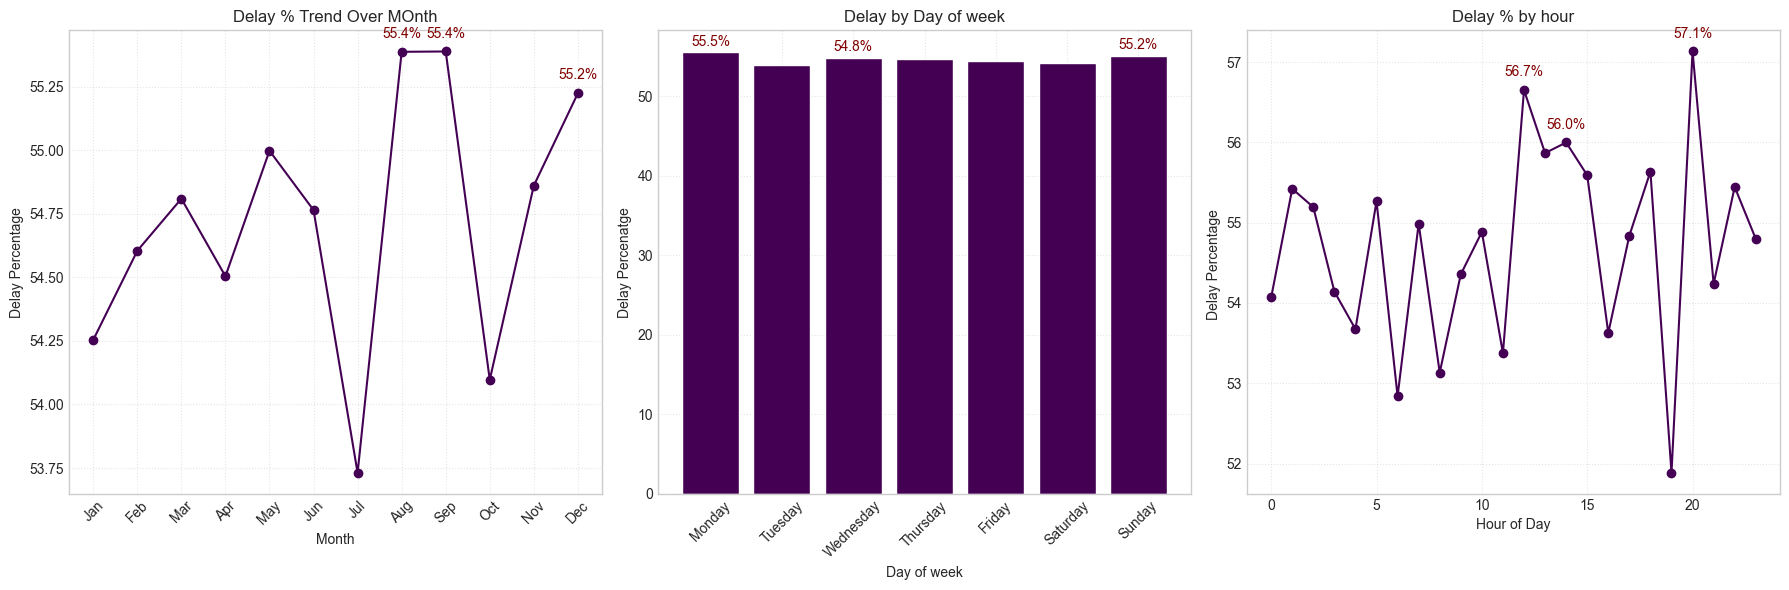

In [79]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18,6))

ax1.plot(delay_by_month['order_month'], delay_by_month['delay_pct'], marker='o', color=primary_color)
ax1.set_xticks(range(1,13))
ax1.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage")
ax1.set_title("Delay % Trend Over MOnth")
ax1.grid(True, linestyle=':', alpha=0.5)

top3_month = delay_by_month.nlargest(3, 'delay_pct')
for _, row in top3_month.iterrows():
    ax1.annotate(f"{row['delay_pct']:.1f}%", (row['order_month'], row['delay_pct']),
                textcoords="offset points", xytext=(0,10), ha='center', fontsize=10, color=danger_color)
    

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
delay_by_day['order_day'] = pd.Categorical(delay_by_day['order_day'], categories=day_order, ordered=True)
delay_by_day = delay_by_day.sort_values('order_day')

ax2.bar(delay_by_day['order_day'], delay_by_day['delay_pct'], color= primary_color)
ax2.set_xticklabels(delay_by_day['order_day'], rotation=45)
ax2.set_xlabel("Day of week")
ax2.set_ylabel("Delay Percenatge")
ax2.set_title("Delay by Day of week")
ax2.grid(True, linestyle = ':', alpha=0.5)

top3_day = delay_by_day.nlargest(3, 'delay_pct')
for _, row in top3_day.iterrows():
    height = row['delay_pct']
    ax2.text(row['order_day'], height + 0.5, f'{height:.1f}%', ha='center', va='bottom', fontsize=10, color=danger_color)

ax3.plot(delay_by_hour['order_hour'], delay_by_hour['delay_pct'], marker='o', color=primary_color)
ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage ")
ax3.set_title("Delay % by hour")
ax3.grid(True, linestyle=':', alpha=0.5)

top3_hour = delay_by_hour.nlargest(3, 'delay_pct')
for _, row in top3_hour.iterrows():
    ax3.annotate(f"{row['delay_pct']:.1f}%", (row['order_hour'], row['delay_pct']),
                textcoords='offset points', xytext=(0,10), ha='center', fontsize=10, color=danger_color)
    
plt.tight_layout()
plt.show()

